## Source documents

This document was the base of the program.
- https://pytorch-forecasting.readthedocs.io/en/v1.4.0/tutorials/stallion.html <br>

This is the paper that introduced TFT.
- https://arxiv.org/abs/1912.09363

General pytorch loading documentation and second TFT example with darts.
- https://docs.pytorch.org/docs/stable/generated/torch.load.html <br>
- https://unit8co.github.io/darts/examples/13-TFT-examples.html <br>

## Packages, and requirements

In [88]:
#Packages and settings
%load_ext autoreload
%autoreload 2
%matplotlib inline

#basic packages
import warnings
import random
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import shutil, os

#Graphing
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

#ML
from pytorch_lightning.callbacks import EarlyStopping
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

#pytorch
import torch
import torch.serialization
from torch.utils.data import DataLoader, TensorDataset
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.tuner import Tuner
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from pytorch_forecasting.metrics import MASE, MAPE
from pytorch_optimizer import Ranger

#Tensorflow
import tensorflow as tf
import tensorboard as tb

#Misc.
from typing import List, Optional
from statsmodels.stats.outliers_influence import variance_inflation_factor
import holidays
import pickle
from tqdm import tqdm
from dtaidistance import dtw as _dtw

#Ignore warnings
import logging
warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
#set seed
seed = 1

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)
pl.seed_everything(42)

42

In [90]:
#Feature selection and cleaning
df = pd.read_csv("./data/processed/processed_data_pre_model.csv") 

# storing raw data in variable for checks
df_raw = pd.read_csv("./data/processed/processed_data_pre_model.csv") 

# Ensure date is datetime and sort
df = df.sort_values(['state', 'date'])

# Drop rows where median_listing_price is NA
df = df.dropna(subset=['median_listing_price'])

# these features are duplicative of median_listing_price. TFT splits variables to prevent leakage but these features will be noise.
df.drop(columns=['average_listing_price'
, 'median_listing_price_per_square_foot'
, 'median_listing_price_vs_us'], inplace=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')

## Data Exploration

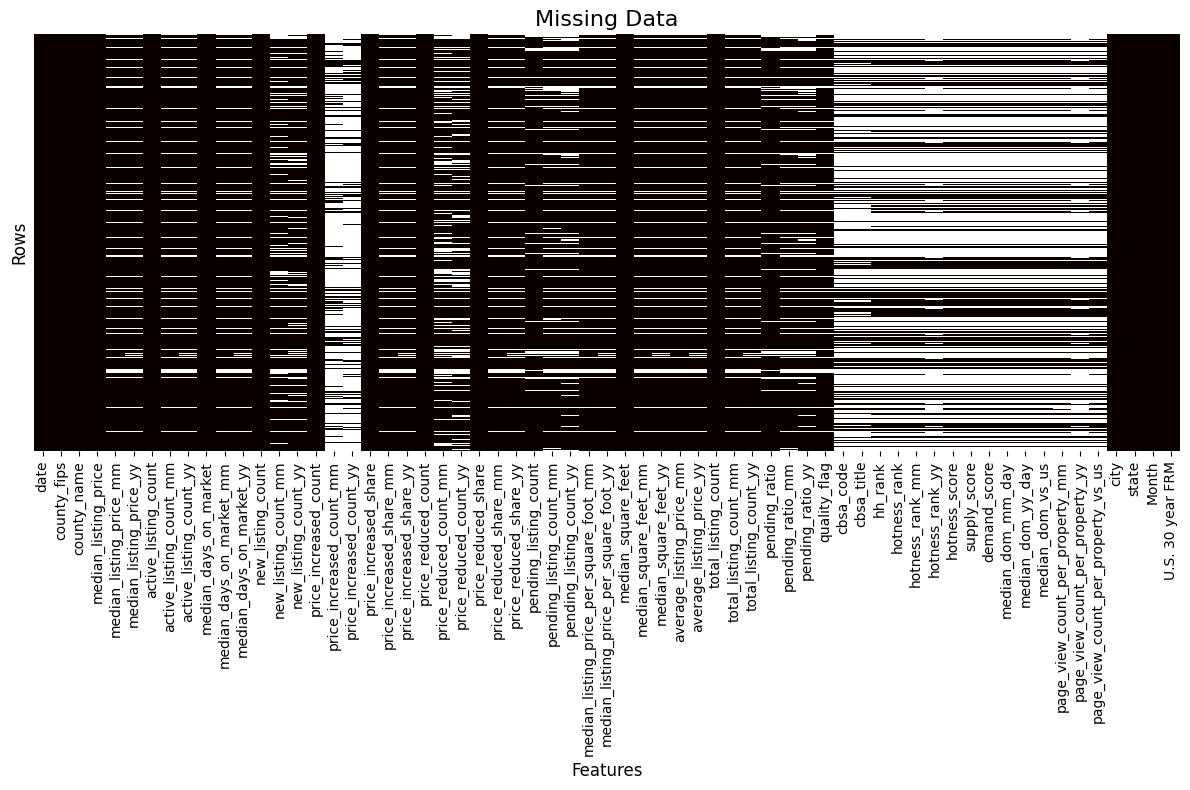

In [91]:
# Create a heatmap showing the missing data of the reduced dataset
plt.figure(figsize=(12, 8))
# df.isnull() creates a boolean mask where True indicates missing values
sns.heatmap(df.isnull(), cbar=False, cmap='hot', yticklabels=False)
plt.title('Missing Data', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.tight_layout()
plt.show()

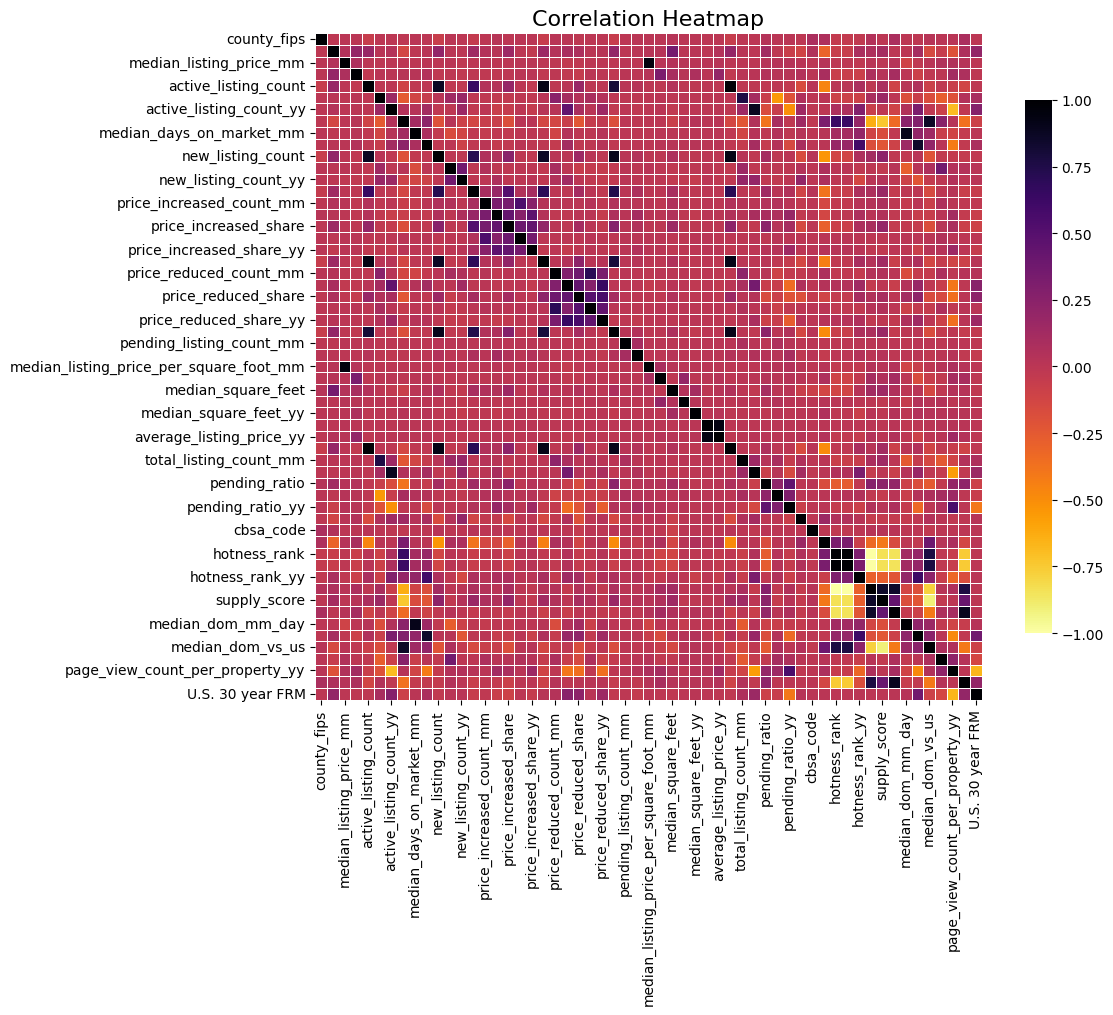

In [92]:
columns_to_plot = df.columns

plt.figure(figsize=(12, 10))

# Compute correlation matrix
corr_matrix = df[columns_to_plot].corr(numeric_only=True)

# Plot
sns.heatmap(
    corr_matrix,
    annot=False,
    fmt=".2f",
    cmap='inferno_r',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

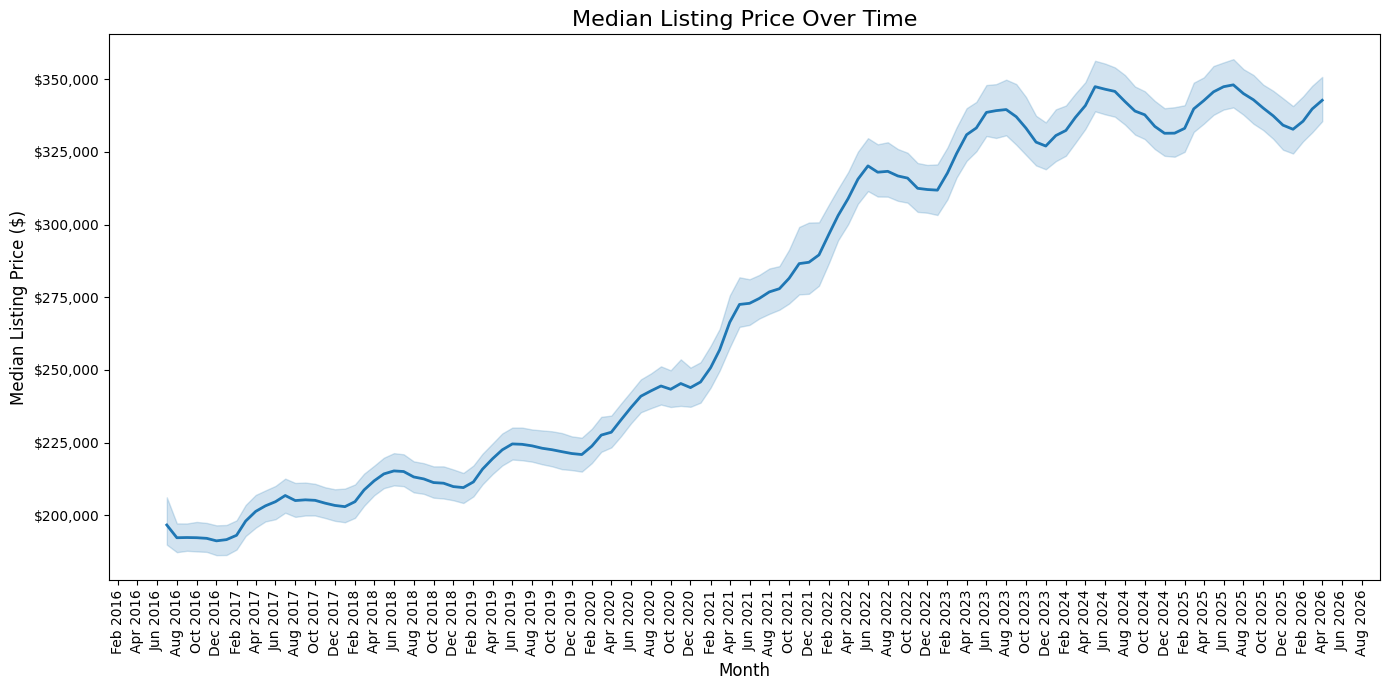

In [93]:
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date (important for time series plots)
df = df.sort_values('date')

# Create the figure
plt.figure(figsize=(14, 7))

# Line plot of median listing price over time
sns.lineplot(
    data=df,
    x='date',
    y='median_listing_price',
    linewidth=2
)

# Title and labels
plt.title('Median Listing Price Over Time', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Median Listing Price ($)', fontsize=12)

# Format y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

# Format x-axis as monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

### Notes on data exploration
- **Missing data**: The hotness dataset is sparce. Imputation will be required for input into TFT.
- **Correlation**: Many variables are highly correlated. TFT has variable selection and past vs. future covariates built in but removing the highly correlated features will reduce noise.
- **Target time series**: Median listing price has three major regimes; before, during, and after COVID. Ensuring that the imputation strategy takes into account the regime of the missing data point will help ensure other features behave like the regime

## Data cleaning and model prep

In [94]:
# Drop columns with correlation >= 0.9 with any other column
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

# Upper triangle mask to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns where any correlation exceeds threshold
threshold = 0.9
cols_to_drop_corr = [col for col in upper.columns if any(upper[col] >= threshold)]

print(f"Dropping {len(cols_to_drop_corr)} highly correlated columns (>= {threshold}):")
print(cols_to_drop_corr)

df = df.drop(columns=cols_to_drop_corr)

Dropping 8 highly correlated columns (>= 0.9):
['price_reduced_count', 'median_listing_price_per_square_foot_mm', 'average_listing_price_yy', 'total_listing_count', 'hotness_rank_mm', 'hotness_score', 'median_dom_mm_day', 'median_dom_vs_us']


In [95]:
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month

In [96]:
df

,date,county_fips,county_name,median_listing_price,median_listing_price_mm,median_listing_price_yy,active_listing_count,active_listing_count_mm,active_listing_count_yy,median_days_on_market,...,median_dom_yy_day,page_view_count_per_property_mm,page_view_count_per_property_yy,page_view_count_per_property_vs_us,city,state,Month,U.S. 30 year FRM,year,month
67,2016-07-01,2013,"aleutians east borough, ak",485000.0,NaN,NaN,3,NaN,NaN,349.0,...,NaN,NaN,NaN,NaN,aleutians east borough,ak,2016-07-01,3.440,2016,7
1252,2016-07-01,26067,"ionia, mi",140950.0,NaN,NaN,143,NaN,NaN,67.0,...,NaN,NaN,NaN,NaN,ionia,mi,2016-07-01,3.440,2016,7
1253,2016-07-01,26069,"iosco, mi",119900.0,NaN,NaN,694,NaN,NaN,75.0,...,NaN,NaN,NaN,NaN,iosco,mi,2016-07-01,3.440,2016,7
1254,2016-07-01,26071,"iron, mi",119000.0,NaN,NaN,245,NaN,NaN,99.0,...,NaN,NaN,NaN,NaN,iron,mi,2016-07-01,3.440,2016,7
1255,2016-07-01,26073,"isabella, mi",139900.0,NaN,NaN,484,NaN,NaN,83.0,...,NaN,NaN,NaN,NaN,isabella,mi,2016-07-01,3.440,2016,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363645,2026-04-01,13201,"miller, ga",179700.0,0.1594,-0.0773,14,0.0769,0.8667,55.0,...,NaN,NaN,NaN,NaN,miller,ga,2026-04-01,6.332,2026,4
363646,2026-04-01,13205,"mitchell, ga",161250.0,0.0323,-0.2986,47,-0.1681,0.2368,129.0,...,NaN,NaN,NaN,NaN,mitchell,ga,2026-04-01,6.332,2026,4
363647,2026-04-01,13207,"monroe, ga",481975.0,-0.0279,0.1740,118,0.0633,0.2842,54.0,...,-13.75,0.021346,0.043500,1.018907,monroe,ga,2026-04-01,6.332,2026,4
363638,2026-04-01,13187,"lumpkin, ga",467450.0,-0.0533,-0.1283,159,0.0931,0.1784,48.0,...,11.50,-0.128113,-0.207414,1.231228,lumpkin,ga,2026-04-01,6.332,2026,4


In [97]:
#gathering holidays for df, creating a feature, and joining
us_holidays = holidays.US(years=df['year'].unique())

holiday_df = pd.DataFrame({
    "date": list(us_holidays.keys()),
    "is_holiday": 1
})

holiday_df['date'] = pd.to_datetime(holiday_df["date"])

df = pd.merge(df,holiday_df,how='left',on='date')

df['is_holiday'] = df['is_holiday'].fillna(0)

# Drop duplicate columns (keep first occurrence)
df = df.loc[:, ~df.columns.duplicated()]

#cleaning before model use
df['is_holiday'] = df['is_holiday'].astype('str')
df['month'] = df['month'].astype('str')

# Remove special characters from column names for model compatibility
df.columns = (
    pd.Index(df.columns.astype(str))
    .str.replace(r"[^0-9A-Za-z_]+", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Drop columns with a high percentage of null values and store dropped columns in a DataFrame
null_threshold = 0.5  # Drop columns with more than 50% nulls (adjust as needed)
null_frac = df.isnull().mean()
cols_to_drop = null_frac[null_frac > null_threshold].index.tolist()
dropped_cols_df = pd.DataFrame({'dropped_column': cols_to_drop, 'null_fraction': null_frac[cols_to_drop].values})
df = df.drop(columns=cols_to_drop)
df = df.drop(columns=['county_fips','city','county_name'])

In [98]:
# Choose the column to group by
group_col = ['state', 'year', 'month','is_holiday']

# Build aggregation dictionary
agg_dict = {}
for col in df.columns:
    if col in group_col:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        agg_dict[col] = 'mean' 
    else:
        agg_dict[col] = 'max'

# Perform the groupby aggregation
df = df.groupby(group_col).agg(agg_dict).reset_index()

In [99]:
max_prediction_length = 12
#Choose columns to exclude from time_varying_unknown_reals
cols_to_exclude = ['date', 'city', 'state','county_fips', 'median_listing_price_x','median_listing_price_mm_x','median_listing_price_yy_x']

# Only use numeric columns for time_varying_unknown_reals
numeric_cols = df.select_dtypes(include=[np.number]).columns
time_varying_unknown_reals = [col for col in numeric_cols if col not in cols_to_exclude]

remaining_cols = time_varying_unknown_reals

#reals = “how much?”
#categoricals = “which type?”

static_categoricals = ["state"]

time_varying_known_reals = ["date"]
time_varying_known_categoricals = ["is_holiday", "month"]
time_varying_unknown_categoricals = []


df['date'] = pd.to_datetime(df['date'])
Start_date = df['date'].min()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
if not df.empty:
    df["time_idx"] = df["date"].dt.year * 12 + df["date"].dt.month
    df["time_idx"] -= df["time_idx"].min()
else:
    raise ValueError("DataFrame is empty after date conversion.")

training_cutoff = df["time_idx"].max() - max_prediction_length

In [100]:
# DTW-KNN imputation
# - Past-only: candidate windows are strictly before the missing point (no leakage)
# - Local regime: DTW over a sliding window of recent values
# - Seasonal signal: circular month distance + quarter + is_holiday
#   (day-of-week omitted — data is monthly after groupby aggregation)
# - Weighted average of K neighbours (weight = 1 / DTW distance)

def dtw_knn_impute(
    df: pd.DataFrame,
    cols: list,
    k: int = 5,
    window_size: int = 6,
    seasonal_weight: float = 0.3,
) -> pd.DataFrame:
    """
    Impute missing values per group (state) using DTW-based KNN with:
      - Strictly past-only candidate windows (no future leakage)
      - DTW distance on z-normalised lookback windows
      - Seasonal penalty: circular month distance + quarter gap + holiday mismatch
      - Inverse-distance weighted average of K nearest neighbours

    Parameters
    ----------
    df              : DataFrame sorted by (state, time_idx)
    cols            : numeric columns to impute
    k               : number of nearest neighbours
    window_size     : length of the lookback window for DTW comparison
    seasonal_weight : weight of the seasonal distance component
    """
    df = df.copy()

    # Pre-compute integer seasonal helpers (month/is_holiday are strings after earlier cells)
    df['_m']  = df['month'].astype(float).astype(int)
    df['_h']  = df['is_holiday'].astype(float).astype(int)
    df['_qt'] = ((df['_m'] - 1) // 3) + 1   # quarter 1–4

    states = df['state'].unique()

    for state in tqdm(states, desc="States"):
        s_mask    = df['state'] == state
        s_df      = df[s_mask].sort_values('time_idx')
        s_orig_idx = s_df.index.tolist()
        n          = len(s_df)

        m_arr  = s_df['_m'].values.astype(int)
        h_arr  = s_df['_h'].values.astype(int)
        qt_arr = s_df['_qt'].values.astype(int)

        for col in cols:
            vals = s_df[col].values.astype(float)   # working copy; updates propagate forward

            for i in range(n):
                if not np.isnan(vals[i]):
                    continue

                # ── Query window: up to window_size past values ──────────────
                q_raw = vals[max(0, i - window_size) : i].copy()
                if len(q_raw) < 2:
                    continue   # series too short; handled by fallback below

                # Fill any residual NaNs in the query for distance computation
                q_s = pd.Series(q_raw).interpolate(limit_direction='both').ffill().bfill().values
                if np.isnan(q_s).any():
                    continue

                q_std  = q_s.std()
                q_norm = (q_s - q_s.mean()) / q_std if q_std > 0 else np.zeros_like(q_s)

                dists, c_vals = [], []

                # ── Candidate windows: strictly before position i ────────────
                for j in range(window_size, i):
                    if np.isnan(vals[j]):
                        continue

                    c_raw = vals[j - window_size : j].copy()
                    c_s   = pd.Series(c_raw).interpolate(limit_direction='both').ffill().bfill().values
                    if np.isnan(c_s).any():
                        continue

                    c_std  = c_s.std()
                    c_norm = (c_s - c_s.mean()) / c_std if c_std > 0 else np.zeros_like(c_s)

                    # DTW on z-normalised windows
                    d_dtw = _dtw.distance(q_norm.astype(np.double), c_norm.astype(np.double))

                    # Seasonal distance components
                    month_gap  = abs(m_arr[i] - m_arr[j])
                    d_month    = min(month_gap, 12 - month_gap) / 6.0          # 0–1
                    d_holiday  = abs(h_arr[i]  - h_arr[j])                     # 0 or 1
                    d_quarter  = abs(qt_arr[i] - qt_arr[j]) / 3.0              # 0–1

                    d_seasonal = seasonal_weight * (d_month + d_holiday + d_quarter)

                    dists.append(d_dtw + d_seasonal)
                    c_vals.append(vals[j])

                if not dists:
                    continue

                dists  = np.array(dists)
                c_vals = np.array(c_vals)
                k_n    = min(k, len(dists))
                top_k  = np.argsort(dists)[:k_n]
                kd, kv = dists[top_k], c_vals[top_k]

                # Weighted average; fall back to plain mean if a perfect match exists
                vals[i] = (
                    kv[kd == 0].mean()
                    if kd.min() == 0
                    else np.average(kv, weights=1.0 / kd)
                )

            # Write imputed column back to df for this state
            for ii, orig_i in enumerate(s_orig_idx):
                df.at[orig_i, col] = vals[ii]

    df.drop(columns=['_m', '_h', '_qt'], inplace=True)
    return df


# ── Run ──────────────────────────────────────────────────────────────────────
_excl        = {'time_idx', 'year'}
impute_cols  = [c for c in df.select_dtypes(include=[np.number]).columns if c not in _excl]

print(f"DTW-KNN imputation | {len(impute_cols)} columns | {df['state'].nunique()} states "
      f"| window={6}, k={5}, seasonal_weight={0.3}")

df = dtw_knn_impute(df, cols=impute_cols, k=5, window_size=6, seasonal_weight=0.3)

# Fallback: rows at the start of a series that are too short to form a full window
df[impute_cols] = df[impute_cols].ffill().bfill()
print("Imputation complete.")


DTW-KNN imputation | 36 columns | 51 states | window=6, k=5, seasonal_weight=0.3


States: 100%|██████████| 51/51 [00:03<00:00, 15.64it/s]

Imputation complete.


In [101]:
df['state'].unique()

array(['ak', 'al', 'ar', 'az', 'ca', 'co', 'ct', 'dc', 'de', 'fl', 'ga',
       'hi', 'ia', 'id', 'il', 'in', 'ks', 'ky', 'la', 'ma', 'md', 'me',
       'mi', 'mn', 'mo', 'ms', 'mt', 'nc', 'nd', 'ne', 'nh', 'nj', 'nm',
       'nv', 'ny', 'oh', 'ok', 'or', 'pa', 'ri', 'sc', 'sd', 'tn', 'tx',
       'ut', 'va', 'vt', 'wa', 'wi', 'wv', 'wy'], dtype=object)

In [102]:
training = TimeSeriesDataSet(
    df[lambda x: x['time_idx'] <= training_cutoff],
    time_idx="time_idx",
    target="median_listing_price",
    group_ids=["state"],
    min_encoder_length=36// 2,
    max_encoder_length=36 , #3 years
    min_prediction_length=1,
    max_prediction_length=12,
    static_categoricals=["state"],
    time_varying_known_categoricals=["is_holiday", "month"], #treat these like labels
    time_varying_known_reals=["date"],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=remaining_cols,
    target_normalizer=GroupNormalizer(
        groups=["state"], transformation="softplus"
    ),  # use softplus and normalize by group
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True, #review data for missing timesteps
)

# create validation set (predict=True) which means to predict the last max_prediction_length points in time
# for each series
validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)
# create dataloaders for model
batch_size = 128  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=0
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10, num_workers=0
)

# Training and Tuning

In [103]:
#confirm gpu is available and set accelerator
print("gpu" if torch.cuda.is_available() else "cpu")
accelerator = "gpu" if torch.cuda.is_available() else "cpu"

gpu


In [104]:
# configure network and trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=accelerator,
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # coment in for training, running valiation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)


In [105]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=5.623413251903491e-05,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.13732124877619326,
    hidden_continuous_size=128,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer=Ranger,
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

Number of parameters in network: 3970.2k


### Toggle for learning rate finder

### Toggle for tuning. Ran in 198 minutes on 05-09-2026

# Train model

In [106]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

# save to repo folder
os.makedirs('./models', exist_ok=True)
best_model_path = trainer.checkpoint_callback.best_model_path
shutil.copy(best_model_path, './models/tft_housing.ckpt')
print(f"Model saved to: ./models/tft_housing.ckpt")

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    788 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │ 10.8 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  201 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.8 M │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  135 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  132 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  132 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    903 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.0 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 666                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Model saved to: ./models/tft_housing.ckpt


# Load model from checkpoint

In [107]:

import torch.serialization

# torch.load may have a stale recursive monkey-patch from a prior cell.
# Anchoring to torch.serialization.load (never patched by the darts cells)
# breaks the chain and forces weights_only=False for pytorch-forecasting checkpoints.
_canon_load = torch.serialization.load

def _load_compat(*args, **kwargs):
    kwargs['weights_only'] = False
    return _canon_load(*args, **kwargs)

torch.load = _load_compat
torch.serialization.load = _load_compat

# map_location: Lightning expects "cuda" not "gpu"
_map_location = "cuda" if accelerator == "gpu" else "cpu"

try:
    best_tft = TemporalFusionTransformer.load_from_checkpoint(
        "./models/tft_housing.ckpt",
        map_location=_map_location,
    )
    best_tft.eval()
    print("Model loaded successfully.")
finally:
    torch.load = _canon_load
    torch.serialization.load = _canon_load


Model loaded successfully.


In [108]:
# Calculate mean absolute error on validation set
predictions = best_tft.predict(
    val_dataloader,
    return_y=True,
    trainer_kwargs=dict(accelerator=accelerator)
)

_device    = predictions.output.device          # already on GPU
output_gpu = predictions.output                 # already there
y_gpu      = (
    predictions.y[0].to(predictions.output.device),
    predictions.y[1].to(predictions.output.device) if isinstance(predictions.y[1], torch.Tensor) else predictions.y[1],
)

print("MAE: ", MAE()(output_gpu, y_gpu))
print("MAPE:", MAPE()(output_gpu, y_gpu))

####### predictions.output is on GPU, predictions.y is a tuple on CPU — move both to CPU
######output_cpu = predictions.output.cpu()
######y_cpu      = (predictions.y[0].cpu(), predictions.y[1])
######
######print("MAE: ", MAE()(output_cpu, y_cpu))
######print("MAPE:", MAPE()(output_cpu, y_cpu))

MAE:  tensor(10946.1562)
MAPE: tensor(0.0252)


In [109]:
# raw predictions are a dictionary from which all kind of information including quantiles can be extracted
raw_predictions = best_tft.predict(
    val_dataloader, mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator=accelerator)
)

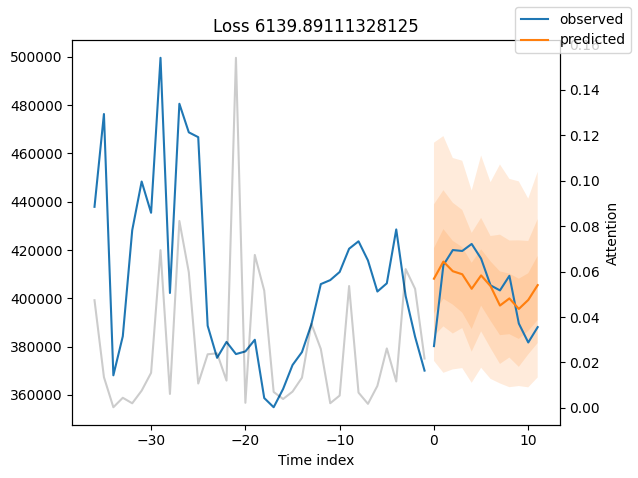

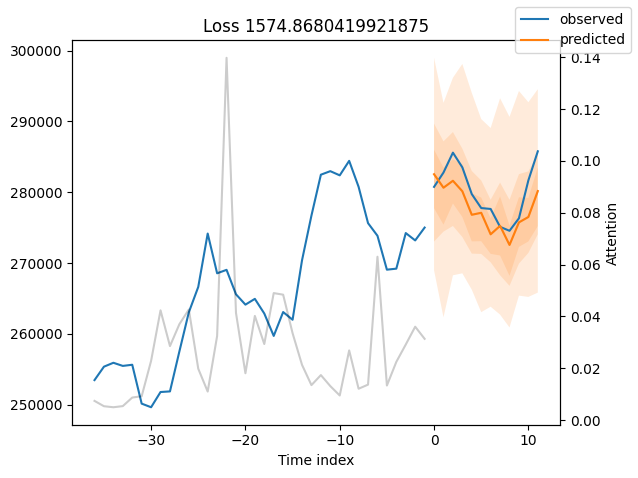

In [110]:
for idx in range(2):  # plot 10 examples
    best_tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=idx,
        add_loss_to_title=True
    )


Worst Proformers

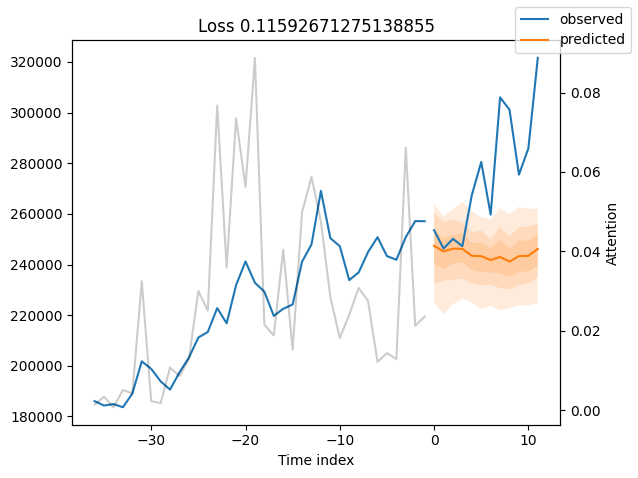

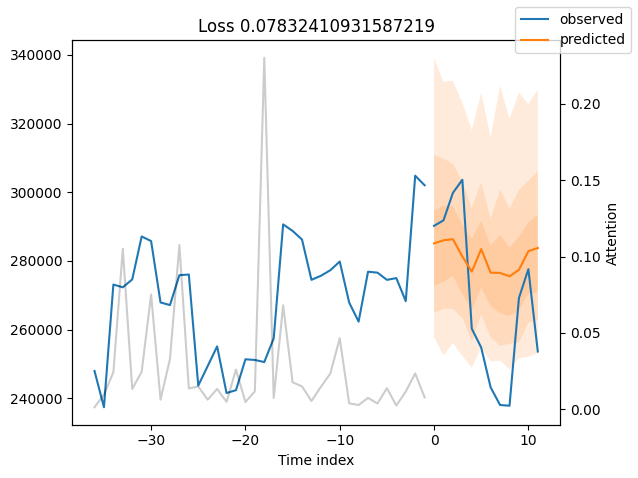

In [111]:
# calcualte metric by which to display
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator=accelerator))

mean_losses = SMAPE(reduction="none").loss(predictions.output, predictions.y[0].to(predictions.output.device)).mean(1)
indices = mean_losses.argsort(descending=True)  # sort losses

for idx in range(2):  # plot 10 examples
    best_tft.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=indices[idx],
        add_loss_to_title=SMAPE(quantiles=best_tft.loss.quantiles),
    )

# Actuals vs predictions by variables

### Toggle for metric validation

### Predict on selected data

In [113]:
california_windows = training.decoded_index[lambda x: x.state == "ca"]
if california_windows.empty:
    raise ValueError("No California subsequences are available in the training dataset.")

selected_time_idx = california_windows['time_idx_first_prediction'].max()

best_tft.predict(
    training.filter(
        lambda x: (x.state == "ca")
        & (x.time_idx_first_prediction == selected_time_idx)
    ),
    mode="quantiles",
    trainer_kwargs=dict(accelerator=accelerator),
)

tensor([[[695822.8750, 708715.6875, 713666.5000, 723405.6875, 729793.7500,
          736395.5625, 748328.5000]]])

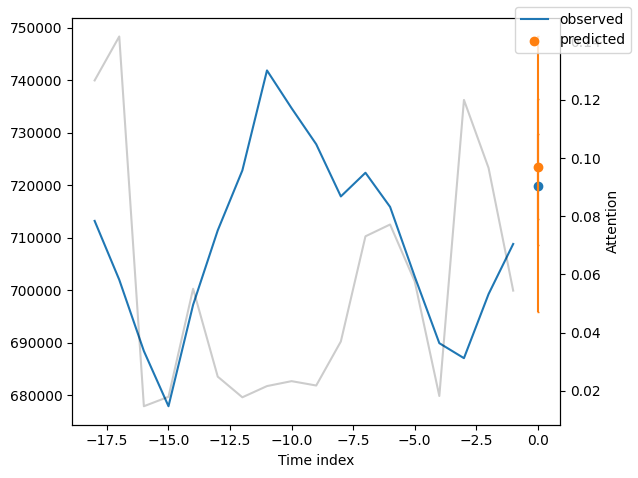

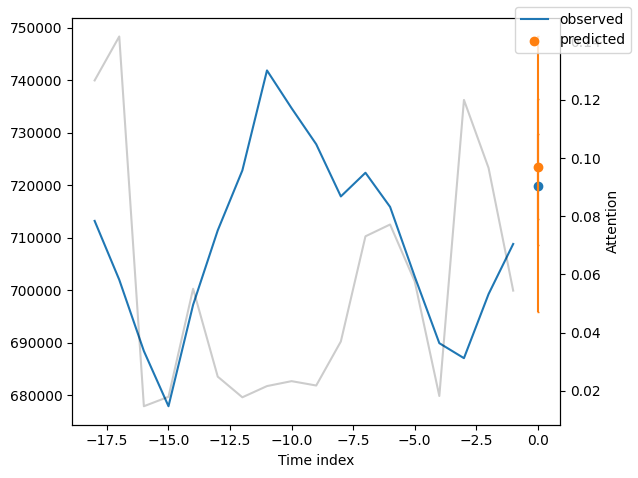

In [114]:
california_windows = training.decoded_index[lambda x: x.state == "ca"]
if california_windows.empty:
    raise ValueError("No California subsequences are available in the training dataset.")

selected_time_idx = california_windows['time_idx_first_prediction'].max()

raw_prediction = best_tft.predict(
    training.filter(
        lambda x: (x.state == "ca")
        & (x.time_idx_first_prediction == selected_time_idx)
    ),
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator=accelerator),
)
best_tft.plot_prediction(raw_prediction.x, raw_prediction.output, idx=0)

Predict on new data

In [117]:
encoder_length = 36

if "time_idx" not in df.columns:
    if "date" not in df.columns:
        raise KeyError("df must contain a 'date' column to rebuild time_idx.")
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])
    df["time_idx"] = df["date"].dt.year * 12 + df["date"].dt.month
    df["time_idx"] -= df["time_idx"].min()

# select last encoder window from the grouped state-level data
encoder_data = df[lambda x: x["time_idx"] > x["time_idx"].max() - encoder_length]

# select last known data point and create decoder data from it by repeating it and incrementing the month
# in a real world dataset, we should not just forward fill the covariates but specify them to account
# for changes in special days and prices (which you absolutely should do but we are too lazy here)
last_data = df[lambda x: x["time_idx"] == x["time_idx"].max()]
decoder_data = pd.concat(
    [
        last_data.assign(date=lambda x: x.date + pd.offsets.MonthBegin(i))
        for i in range(1, max_prediction_length + 1)
    ],
    ignore_index=True,
)

# add time index consistent with "data"
decoder_data["time_idx"] = (
    decoder_data["date"].dt.year * 12 + decoder_data["date"].dt.month
)
decoder_data["time_idx"] += (
    encoder_data["time_idx"].max() + 1 - decoder_data["time_idx"].min()
)

# adjust additional time feature(s)
decoder_data["year"] = decoder_data.date.dt.year
decoder_data["month"] = decoder_data.date.dt.month.astype(str).astype(
    "category"
)  # categories have be strings

future_holidays = holidays.US(years=decoder_data["year"].unique())
future_holiday_dates = set(pd.to_datetime(list(future_holidays.keys())).normalize())
decoder_data["is_holiday"] = (
    decoder_data["date"].dt.normalize().isin(future_holiday_dates).astype(float).astype(str)
)

# combine encoder and decoder data
new_prediction_data = pd.concat([encoder_data, decoder_data], ignore_index=True)

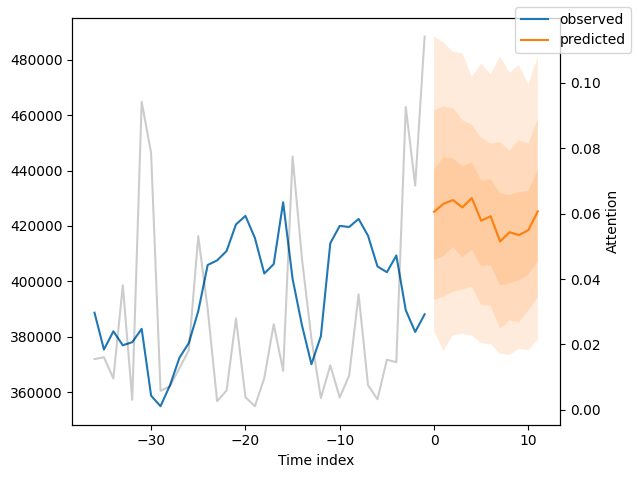

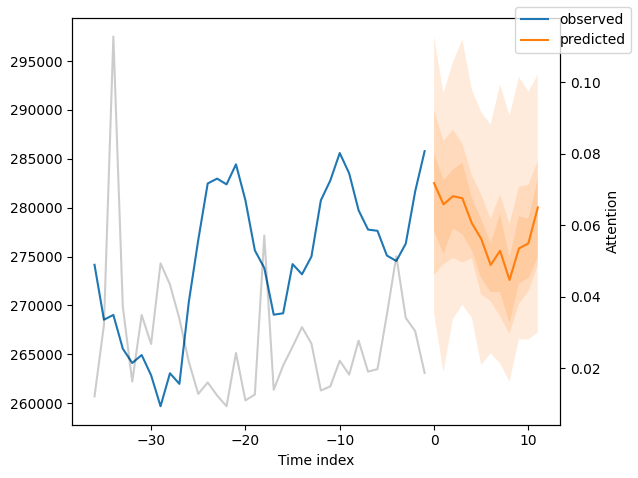

In [118]:
new_raw_predictions = best_tft.predict(
    new_prediction_data,
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator=accelerator),
)

for idx in range(2):  # plot 10 examples
    best_tft.plot_prediction(
        new_raw_predictions.x,
        new_raw_predictions.output,
        idx=idx,
        show_future_observed=False,
    )

Interpret model

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x300 with 1 Axes>,
 'encoder_variables': <Figure size 700x1225 with 1 Axes>,
 'decoder_variables': <Figure size 700x300 with 1 Axes>}

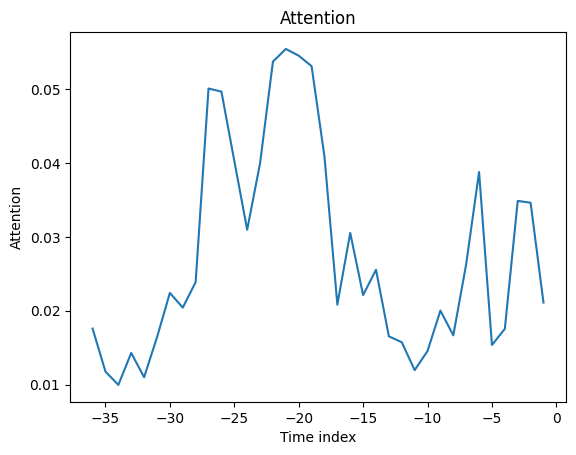

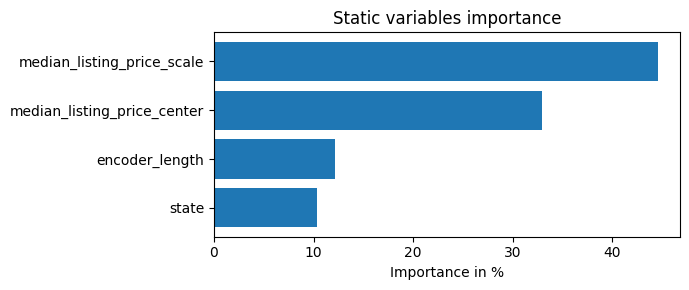

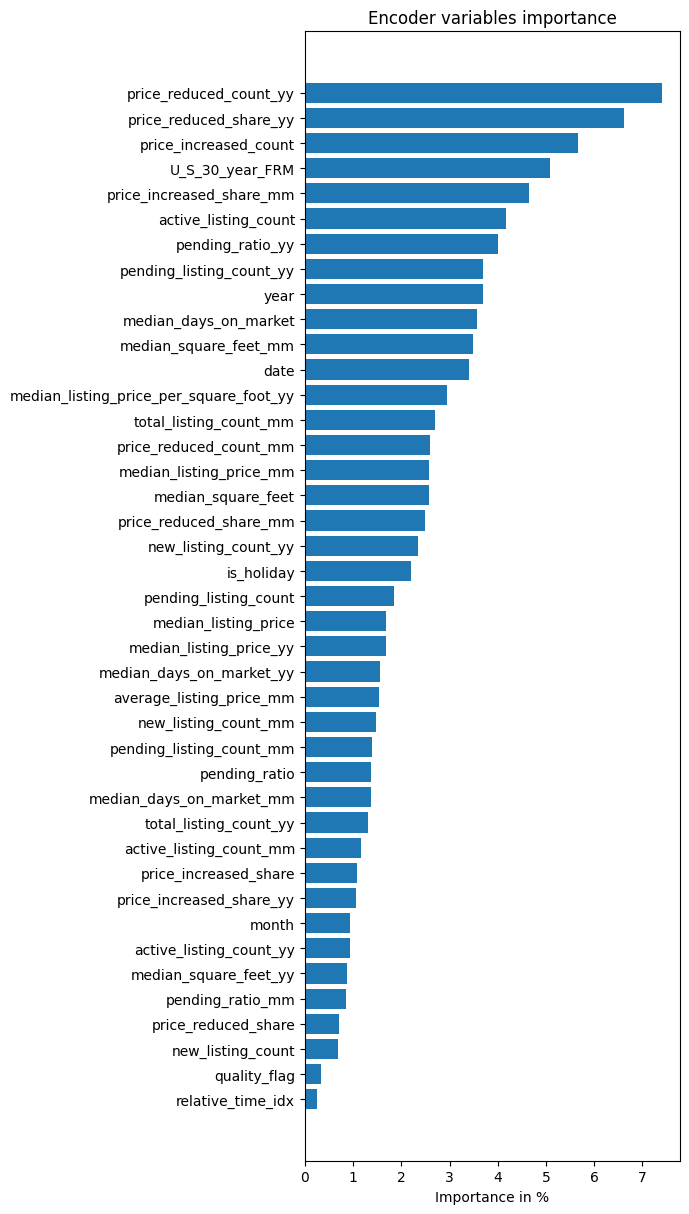

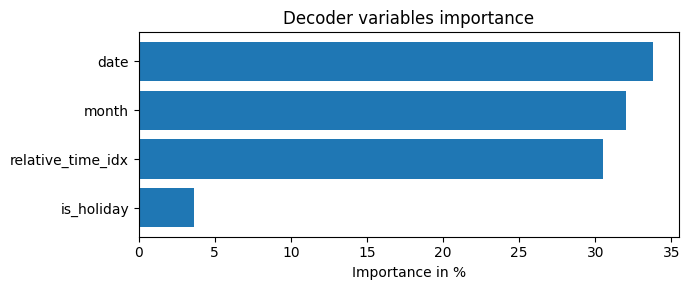

In [119]:
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)

Partial dependency

In [121]:
# Partial dependence on a real variable that actually exists in this trained dataset
preferred_dependency_vars = [
    "median_days_on_market",
    "active_listing_count",
    "pending_listing_count",
    "new_listing_count",
    "price_reduced_count",
]

candidate_dependency_vars = [
    col for col in remaining_cols
    if col not in {"median_listing_price", "time_idx", "year"}
    and pd.api.types.is_numeric_dtype(df[col])
    and df[col].notna().any()
]

if not candidate_dependency_vars:
    raise ValueError("No numeric dependency variables are available in remaining_cols.")

dependency_variable = next(
    (col for col in preferred_dependency_vars if col in candidate_dependency_vars),
    candidate_dependency_vars[0],
)

dependency_source = df[dependency_variable].dropna()
value_min, value_max = dependency_source.quantile([0.05, 0.95])
if np.isclose(value_min, value_max):
    value_min, value_max = dependency_source.min(), dependency_source.max()

dependency_values = np.linspace(value_min, value_max, 30)
print(f"Using dependency variable: {dependency_variable}")

dependency = best_tft.predict_dependency(
    val_dataloader.dataset,
    dependency_variable,
    dependency_values,
    show_progress_bar=True,
    mode="dataframe",
    trainer_kwargs=dict(accelerator=accelerator),
)

Using dependency variable: median_days_on_market


Predict:   0%|          | 0/30 [00:00<?, ? batches/s]

Text(0.5, 0, 'median_days_on_market')

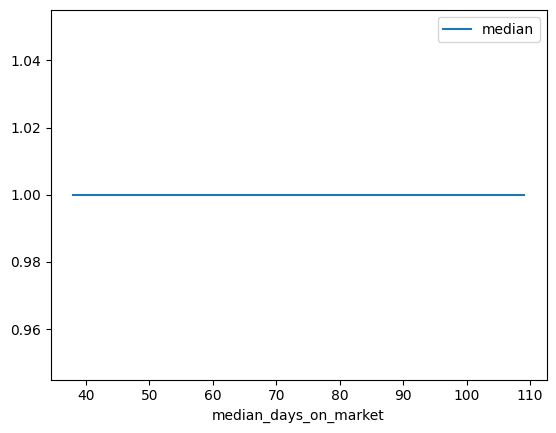

In [122]:
# Plot median with 25th and 75th percentile bands for the selected dependency variable
agg_dependency = dependency.groupby(dependency_variable).normalized_prediction.agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
).sort_index()

ax = agg_dependency.plot(y="median")
ax.fill_between(
    agg_dependency.index,
    agg_dependency.q25,
    agg_dependency.q75,
    alpha=0.3,
 )
ax.set_xlabel(dependency_variable)

- Need to understand this

# Forecasting

Three levels of forecast are generated from the trained TFT model:
1. **National** — average of state-level predictions
2. **State** — direct TFT output (model was trained at this level)
3. **County** — proportional disaggregation: county's historical median-price ratio vs. its state is applied to the state forecast


In [127]:
# ── Load best model ───────────────────────────────────────────────────────────
best_tft = TemporalFusionTransformer.load_from_checkpoint(
    "./models/tft_housing.ckpt",
    map_location="cpu", #gpu cuda:0
)
best_tft.eval()

torch.load("./models/tft_housing.ckpt", map_location="cpu", weights_only=False)

# Quantile index helpers for QuantileLoss [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
_quantiles = best_tft.loss.quantiles
_med_idx = min(range(len(_quantiles)), key=lambda i: abs(_quantiles[i] - 0.5))
_q10_idx = min(range(len(_quantiles)), key=lambda i: abs(_quantiles[i] - 0.1))
_q90_idx = min(range(len(_quantiles)), key=lambda i: abs(_quantiles[i] - 0.9))

# ── Build encoder + decoder data for all states ───────────────────────────────
# time_idx offset is fixed from training: time_idx = year*12 + month - base
_time_idx_base = Start_date.year * 12 + Start_date.month

# Encoder: last 36 months of known data per state
encoder_data = df[df["time_idx"] > df["time_idx"].max() - 36].copy()

# Decoder: 12 future months per state, forward-filling unknown covariates
last_known = df[df["time_idx"] == df["time_idx"].max()].copy()
decoder_frames = []
for i in range(1, 13):
    frame = last_known.copy()
    frame["date"]     = frame["date"] + pd.DateOffset(months=i)
    frame["time_idx"] = frame["date"].dt.year * 12 + frame["date"].dt.month - _time_idx_base
    frame["month"]    = frame["date"].dt.month.astype(str)
    frame["year"]     = frame["date"].dt.year
    decoder_frames.append(frame)

decoder_data = pd.concat(decoder_frames, ignore_index=True)

# Correct is_holiday for future months
_future_holidays      = holidays.US(years=decoder_data["year"].unique())
_future_holiday_dates = set(pd.to_datetime(list(_future_holidays.keys())).normalize())
decoder_data["is_holiday"] = (
    decoder_data["date"].dt.normalize()
    .isin(_future_holiday_dates)
    .astype(float).astype(str)
)

new_prediction_data = pd.concat([encoder_data, decoder_data], ignore_index=True)

# ── Run raw predictions for all states ───────────────────────────────────────
raw_preds = best_tft.predict(
    new_prediction_data,
    mode="raw",
    return_x=True,
    return_index=True,
    trainer_kwargs=dict(accelerator=accelerator),
)

# Prediction tensor: shape (n_series, max_prediction_length, n_quantiles)
_pred_tensor = raw_preds.output.prediction.cpu().numpy()   # (n_states, 12, 7)

# Map each prediction row back to its state name via the returned index
if getattr(raw_preds, "index", None) is None or "state" not in raw_preds.index.columns:
    raise ValueError("Prediction index does not include state labels.")
_pred_states = raw_preds.index["state"].astype(str).to_numpy()

if len(_pred_states) != _pred_tensor.shape[0]:
    raise ValueError(
        f"State label count ({len(_pred_states)}) does not match prediction rows ({_pred_tensor.shape[0]})."
    )

_last_date    = df["date"].max()
_future_dates = pd.date_range(_last_date + pd.DateOffset(months=1), periods=12, freq="MS")

print(f"Model loaded | quantiles: {_quantiles}")
print(f"Predictions: {len(_pred_states)} state series | "
      f"{_future_dates[0].strftime('%b %Y')} – {_future_dates[-1].strftime('%b %Y')}")

Model loaded | quantiles: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
Predictions: 51 state series | May 2026 – Apr 2027


## National Median Listing Price Forecast

Average of all state-level predictions. Because the TFT was trained per-state, the national figure is the mean of state medians — a reasonable proxy but not a weighted-population average.


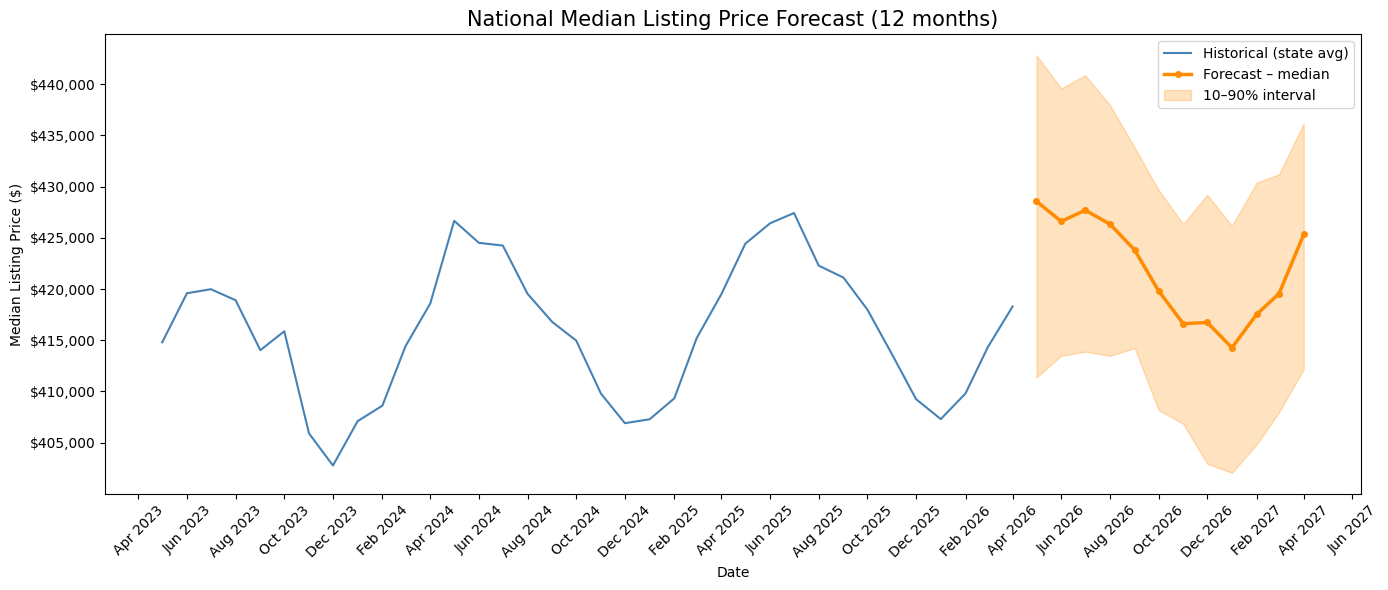


National Forecast (next 12 months):
    date  median_forecast    q10    q90
May 2026           428565 411379 442830
Jun 2026           426597 413475 439584
Jul 2026           427693 413885 440875
Aug 2026           426347 413472 437983
Sep 2026           423815 414231 433831
Oct 2026           419826 408190 429678
Nov 2026           416607 406820 426341
Dec 2026           416738 402937 429214
Jan 2027           414268 402049 426170
Feb 2027           417532 404817 430388
Mar 2027           419542 407951 431206
Apr 2027           425334 412169 436179


In [128]:

# Average state-level predictions → national estimate
national_med = _pred_tensor[:, :, _med_idx].mean(axis=0)   # (12,)
national_q10 = _pred_tensor[:, :, _q10_idx].mean(axis=0)
national_q90 = _pred_tensor[:, :, _q90_idx].mean(axis=0)

# Historical context: mean of state medians per month (last 36 months)
hist_nat = (
    df.groupby("date")["median_listing_price"].mean()
    .reset_index().sort_values("date").tail(36)
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hist_nat["date"], hist_nat["median_listing_price"],
        label="Historical (state avg)", color="steelblue", linewidth=1.5)
ax.plot(_future_dates, national_med,
        label="Forecast – median", color="darkorange", linewidth=2.5, marker="o", markersize=4)
ax.fill_between(_future_dates, national_q10, national_q90,
                alpha=0.25, color="darkorange", label="10–90% interval")
ax.set_title("National Median Listing Price Forecast (12 months)", fontsize=15)
ax.set_xlabel("Date")
ax.set_ylabel("Median Listing Price ($)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

national_forecast_df = pd.DataFrame({
    "date":            _future_dates.strftime("%b %Y"),
    "median_forecast": national_med.round(0).astype(int),
    "q10":             national_q10.round(0).astype(int),
    "q90":             national_q90.round(0).astype(int),
})
print("\nNational Forecast (next 12 months):")
print(national_forecast_df.to_string(index=False))


## State-Level Median Listing Price Forecast

Direct TFT predictions — one series per state. Edit `states_to_plot` to change which states are visualised. `state_forecast_df` contains all states.


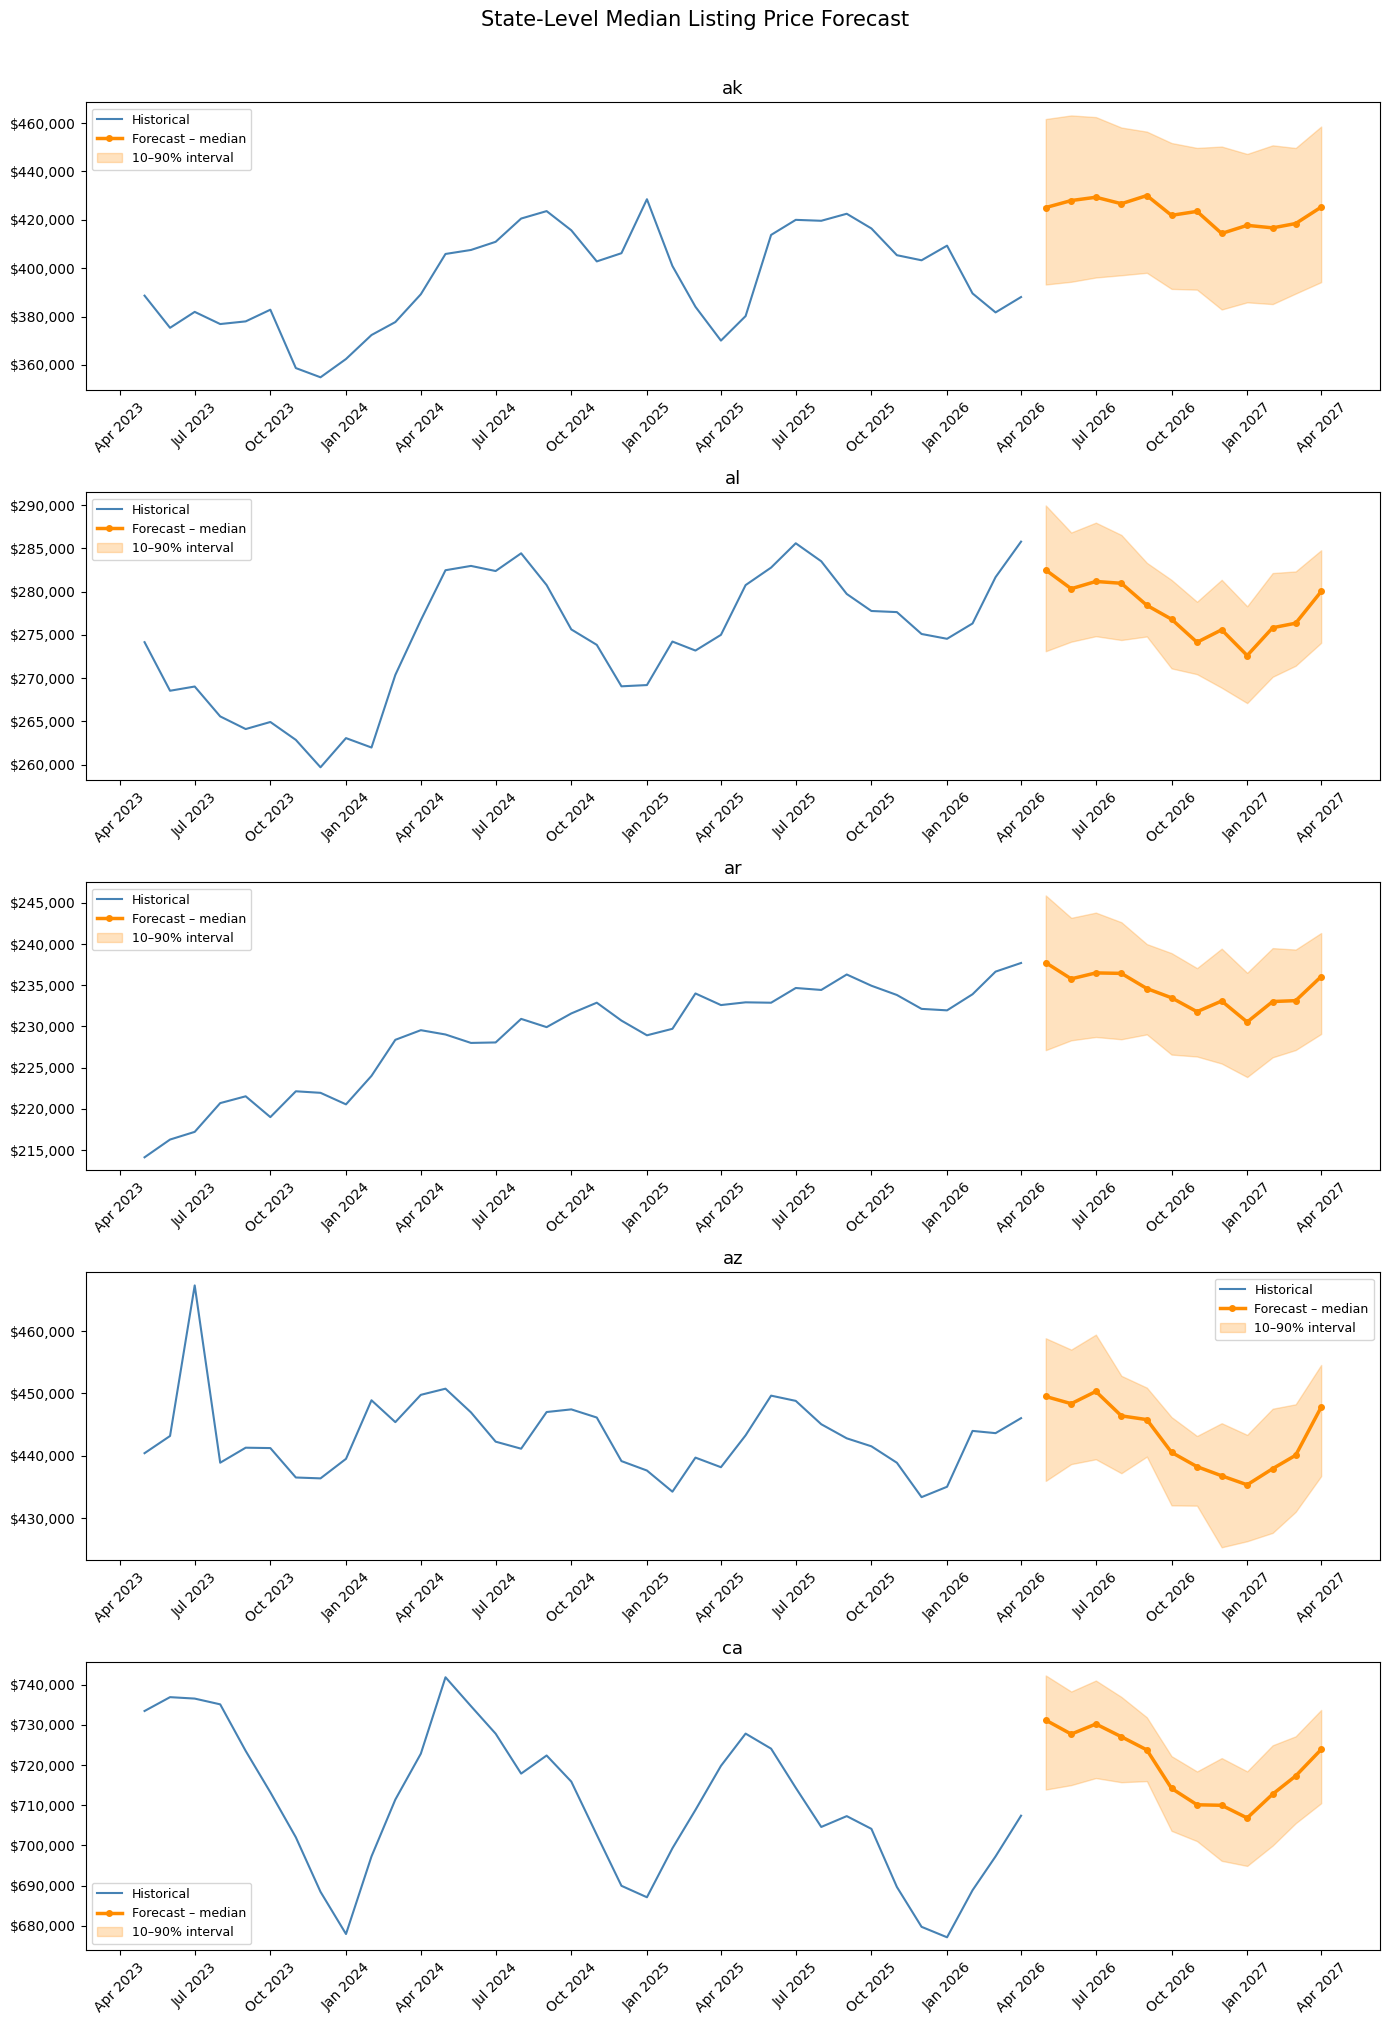


State Forecast Summary (Month 1 vs Month 12):
       next_month    month_12
state                        
ma     $1,118,528  $1,102,500
hi       $988,426  $1,004,777
ca       $731,198    $723,886
ri       $718,894    $708,560
co       $656,539    $653,986
ut       $618,366    $616,672
dc       $616,489    $617,707
wa       $587,662    $582,374
ct       $582,693    $570,693
id       $582,274    $580,172
wy       $564,894    $561,059
nj       $559,028    $551,318
nh       $554,849    $547,878
or       $506,217    $503,400
vt       $494,299    $489,304
de       $480,019    $472,689
mt       $465,676    $469,794
md       $462,658    $455,818
me       $452,078    $447,423
nv       $449,959    $447,071
az       $449,511    $447,805
fl       $425,565    $423,701
ak       $425,073    $425,257
va       $410,341    $405,123
nc       $408,444    $403,956
ny       $398,757    $396,390
tn       $389,752    $386,260
nm       $367,719    $359,839
wi       $366,695    $362,647
sd       $365,151    $3

In [129]:

# Build a flat DataFrame of all state forecasts
state_forecast_rows = []
for idx, state_name in enumerate(_pred_states):
    for t, dt in enumerate(_future_dates):
        state_forecast_rows.append({
            "state":           state_name,
            "date":            dt,
            "median_forecast": _pred_tensor[idx, t, _med_idx],
            "q10":             _pred_tensor[idx, t, _q10_idx],
            "q90":             _pred_tensor[idx, t, _q90_idx],
        })
state_forecast_df = pd.DataFrame(state_forecast_rows)

# ── Plot selected states ──────────────────────────────────────────────────────
states_to_plot = ["California", "Texas", "New York", "Florida", "Colorado"]
states_to_plot = [s for s in states_to_plot if s in state_forecast_df["state"].values]

# Fall back to first 5 available states if none of the above are in the data
if not states_to_plot:
    states_to_plot = sorted(state_forecast_df["state"].unique())[:5]

fig, axes = plt.subplots(len(states_to_plot), 1,
                         figsize=(14, 4 * len(states_to_plot)), sharex=False)
if len(states_to_plot) == 1:
    axes = [axes]

for ax, state in zip(axes, states_to_plot):
    hist_s = df[df["state"] == state].sort_values("date").tail(36)
    fcst_s = state_forecast_df[state_forecast_df["state"] == state]

    ax.plot(hist_s["date"], hist_s["median_listing_price"],
            label="Historical", color="steelblue", linewidth=1.5)
    ax.plot(fcst_s["date"], fcst_s["median_forecast"],
            label="Forecast – median", color="darkorange", linewidth=2.5,
            marker="o", markersize=4)
    ax.fill_between(fcst_s["date"], fcst_s["q10"], fcst_s["q90"],
                    alpha=0.25, color="darkorange", label="10–90% interval")
    ax.set_title(state, fontsize=13)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(fontsize=9)

plt.suptitle("State-Level Median Listing Price Forecast", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Summary table: first and last month forecast per state
summary = (
    state_forecast_df.groupby("state")["median_forecast"]
    .agg(next_month="first", month_12="last")
    .sort_values("next_month", ascending=False)
)
summary["next_month"] = summary["next_month"].map("${:,.0f}".format)
summary["month_12"]   = summary["month_12"].map("${:,.0f}".format)
print("\nState Forecast Summary (Month 1 vs Month 12):")
print(summary.to_string())


## County-Level Median Listing Price Forecast

The TFT was trained at the state level, so county forecasts use **proportional disaggregation**:

$$\hat{p}_{county,t} = \hat{p}_{state,t} \times \tilde{r}_{county}$$

where $\tilde{r}_{county}$ is the median ratio of county price to state price over the most recent 24 months of raw data. Edit `counties_to_plot` to change which counties are visualised. `county_forecast_df` contains all counties.


In [130]:

# ── Compute county-to-state price ratios from raw county data ─────────────────
county_raw = pd.read_csv("./data/processed/processed_data_pre_model.csv")
county_raw["date"]        = pd.to_datetime(county_raw["date"])
county_raw["county_fips"] = county_raw["county_fips"].astype(str).str.replace(".0", "", regex=False).str.strip()
county_raw = county_raw.dropna(subset=["median_listing_price", "county_fips", "state"])

# Use the most recent 24 months to estimate stable ratios
_ratio_cutoff = county_raw["date"].max() - pd.DateOffset(months=24)
recent_county = county_raw[county_raw["date"] >= _ratio_cutoff].copy()

# State median per month (from the raw data, not the grouped model data)
state_monthly = (
    recent_county.groupby(["state", "date"])["median_listing_price"]
    .median().reset_index()
    .rename(columns={"median_listing_price": "state_median"})
)

county_monthly = (
    recent_county.groupby(["state", "county_fips", "date"])["median_listing_price"]
    .median().reset_index()
)

merged_ratios = county_monthly.merge(state_monthly, on=["state", "date"])
merged_ratios["ratio"] = merged_ratios["median_listing_price"] / merged_ratios["state_median"]

# Median ratio per county across the 24-month window (robust to outlier months)
county_ratios = (
    merged_ratios.groupby(["state", "county_fips"])["ratio"]
    .median().reset_index()
    .rename(columns={"ratio": "county_to_state_ratio"})
)

# ── Build county forecast by applying ratios to state TFT predictions ─────────
state_med_map = {s: _pred_tensor[i, :, _med_idx] for i, s in enumerate(_pred_states)}
state_q10_map = {s: _pred_tensor[i, :, _q10_idx] for i, s in enumerate(_pred_states)}
state_q90_map = {s: _pred_tensor[i, :, _q90_idx] for i, s in enumerate(_pred_states)}

county_forecast_rows = []
for _, row in county_ratios.iterrows():
    state = row["state"]
    if state not in state_med_map:
        continue
    ratio = row["county_to_state_ratio"]
    for t, dt in enumerate(_future_dates):
        county_forecast_rows.append({
            "county_fips":     row["county_fips"],
            "state":           state,
            "date":            dt,
            "median_forecast": state_med_map[state][t] * ratio,
            "q10":             state_q10_map[state][t] * ratio,
            "q90":             state_q90_map[state][t] * ratio,
        })

county_forecast_df = pd.DataFrame(county_forecast_rows)

# Attach county names for readability
county_names = (
    county_raw[["county_fips", "county_name", "state"]]
    .drop_duplicates()
    .assign(county_fips=lambda x: x["county_fips"].astype(str).str.replace(".0", "", regex=False).str.strip())
)
county_forecast_df = county_forecast_df.merge(county_names, on=["county_fips", "state"], how="left")

print(f"County forecasts built for {county_forecast_df['county_fips'].nunique()} counties "
      f"across {county_forecast_df['state'].nunique()} states.")
print(county_forecast_df.head(10)[
    ["county_fips", "county_name", "state", "date", "median_forecast", "q10", "q90"]
].to_string(index=False))


County forecasts built for 3130 counties across 51 states.
county_fips                county_name state       date  median_forecast           q10           q90
       2013 aleutians east borough, ak    ak 2026-05-01    134194.484375 124143.351562 145756.390625
       2013 aleutians east borough, ak    ak 2026-06-01    135108.453125 124499.164062 146226.984375
       2013 aleutians east borough, ak    ak 2026-07-01    135541.093750 125057.445312 146009.000000
       2013 aleutians east borough, ak    ak 2026-08-01    134695.718750 125350.945312 144645.890625
       2013 aleutians east borough, ak    ak 2026-09-01    135761.828125 125670.171875 144108.953125
       2013 aleutians east borough, ak    ak 2026-10-01    133179.265625 123569.804688 142623.890625
       2013 aleutians east borough, ak    ak 2026-11-01    133693.515625 123470.992188 141985.125000
       2013 aleutians east borough, ak    ak 2026-12-01    130812.359375 120878.429688 142162.406250
       2013 aleutians east borou

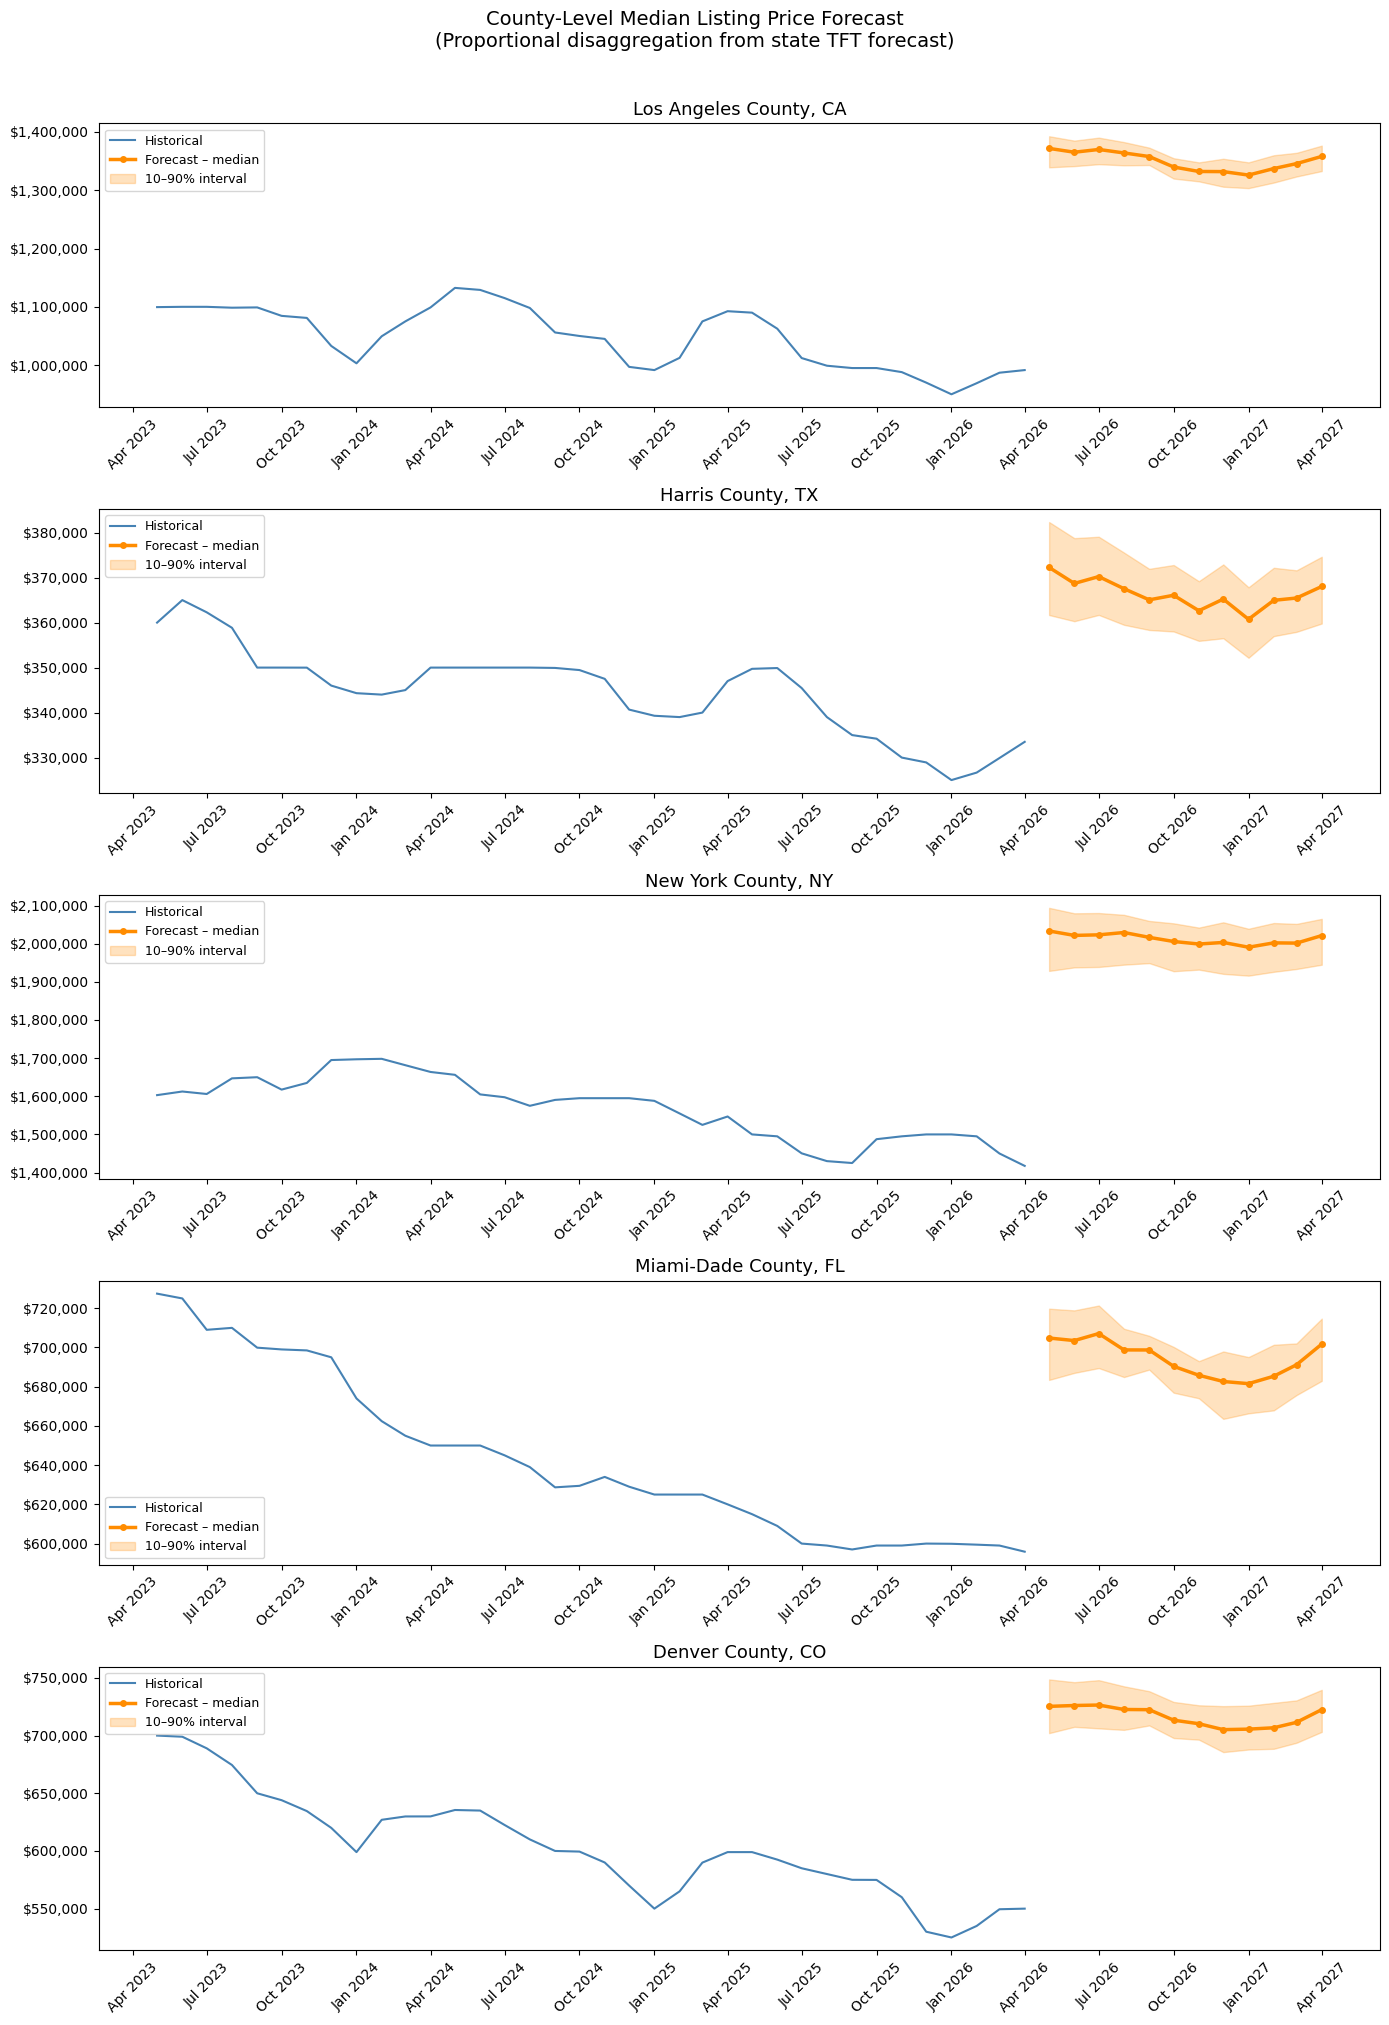

In [131]:

# ── Plot selected counties ────────────────────────────────────────────────────
# Edit this list: (county_fips, display_label)
counties_to_plot = [
    ("6037",  "Los Angeles County, CA"),
    ("48201", "Harris County, TX"),
    ("36061", "New York County, NY"),
    ("12086", "Miami-Dade County, FL"),
    ("8031",  "Denver County, CO"),
]

# Keep only counties that exist in the forecast
available_fips = set(county_forecast_df["county_fips"].unique())
counties_to_plot = [(fips, label) for fips, label in counties_to_plot if fips in available_fips]

# Fall back: first 5 counties by FIPS
if not counties_to_plot:
    fallback = (
        county_forecast_df[["county_fips", "county_name", "state"]]
        .drop_duplicates()
        .sort_values("county_fips")
        .head(5)
    )
    counties_to_plot = [
        (row["county_fips"], f"{row['county_name']}, {row['state']}")
        for _, row in fallback.iterrows()
    ]

fig, axes = plt.subplots(len(counties_to_plot), 1,
                         figsize=(14, 4 * len(counties_to_plot)), sharex=False)
if len(counties_to_plot) == 1:
    axes = [axes]

for ax, (fips, label) in zip(axes, counties_to_plot):
    hist_c = (
        county_raw[county_raw["county_fips"].astype(str).str.replace(".0", "", regex=False).str.strip() == fips]
        .sort_values("date").tail(36)
    )
    fcst_c = county_forecast_df[county_forecast_df["county_fips"] == fips]

    if not hist_c.empty:
        ax.plot(hist_c["date"], hist_c["median_listing_price"],
                label="Historical", color="steelblue", linewidth=1.5)
    ax.plot(fcst_c["date"], fcst_c["median_forecast"],
            label="Forecast – median", color="darkorange", linewidth=2.5,
            marker="o", markersize=4)
    ax.fill_between(fcst_c["date"], fcst_c["q10"], fcst_c["q90"],
                    alpha=0.25, color="darkorange", label="10–90% interval")
    ax.set_title(label, fontsize=13)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(fontsize=9)

plt.suptitle(
    "County-Level Median Listing Price Forecast\n"
    "(Proportional disaggregation from state TFT forecast)",
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()
